# Taller: Abandono de producto financiero

## Regresión logística en Python · Clase 9

**Estudiantes:** Nicolás Montenegro Cedeño - Nicolás Barona
**Base:** `abandono_producto_financiero.csv` (10.000 clientes, corte transversal)

---

### El problema

Una entidad de banca de personas registró un aumento de clientes que cierran la relación. El
área de retención necesita pasar de la tasa agregada de la cartera a una probabilidad
individual:

$$
P(\text{abandono}=1 \mid x) = \Lambda(x\beta) = \frac{e^{x\beta}}{1 + e^{x\beta}} \in (0,1)
$$

El cálculo no sustituye la decisión comercial: ordena la cartera. Dice a quién contactar
primero, con qué umbral se declara a un cliente «en riesgo» y qué error se acepta, llamar a quien
se iba a quedar (falso positivo) frente a no ver a quien sí se va (falso negativo).

`abandono = 1` significa que el cliente cerró la relación; `abandono = 0`, que permanece. No es
mora ni *default*.

### Recorrido

| Sección | Qué se hace | Preguntas |
|---|---|---|
| 1 | Cargar, tipificar y contar variables | 1–4 |
| 2 | Univariado de $y$ y de las $x$ | 5 |
| 3 | Bivariado con `abandono` (boxplots, tablas, ji-cuadrado) | 6–10 |
| 4 | De la recta OLS al logit simple (edad) | 11–13 |
| 5 | Varios logits, AIC, odds ratios | 14–16 |
| 6 | Test, umbral, matriz de confusión e indicadores | 17–18 |
| 7 | Dos perfiles y lectura de riesgo | 19–21 |

Las respuestas están en celdas Markdown debajo de cada bloque de código, y todas las cifras
citadas provienen de esta corrida.

---

## 0. Configuración

Paquetes de clase: `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`. No se usa `sklearn`,
porque el objetivo es inferencia (coeficientes, errores estándar, *odds ratios*) y no solo
predicción.

El CSV debe estar en la misma carpeta que este cuaderno, con el nombre
`abandono_producto_financiero.csv`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import statsmodels
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Paleta fija para las dos clases de la respuesta
COL_PERM, COL_ABAN = "#2C5697", "#C0392B"

print("Versiones utilizadas")
print("-" * 32)
for nombre, mod in [("pandas", pd), ("numpy", np), ("statsmodels", statsmodels),
                    ("scipy", scipy)]:
    print(f"{nombre:12s} {mod.__version__}")

Versiones utilizadas
--------------------------------
pandas       3.0.3
numpy        2.5.0
statsmodels  0.14.6
scipy        1.18.0


In [2]:
# Localización del archivo (debe estar junto al cuaderno)
CANDIDATOS = [Path("abandono_producto_financiero.csv"),
              Path.home() / "Downloads" / "abandono_producto_financiero.csv",
              Path.home() / "Descargas" / "abandono_producto_financiero.csv"]
RUTA = next((p for p in CANDIDATOS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError(
        "No se encontró abandono_producto_financiero.csv. "
        "Colóquelo junto a este cuaderno.")
print(f"Archivo de datos: {RUTA.resolve()}")

Archivo de datos: C:\Users\nicom\Downloads\abandono_producto_financiero.csv


---

# 1. Estructura de los datos

Se carga la base, se inspecciona, se eliminan los identificadores que no entran a la fórmula
(`numero_fila`, `id_cliente`, `apellido`) y se fijan los tipos:

- `pais` → categórica con niveles Francia, Alemania, España (referencia: Francia)
- `sexo` → categórica con niveles Mujer, Hombre (referencia: Mujer)
- `abandono` → entero 0/1

El orden de los niveles importa: es lo que hace que `C(pais)` y `C(sexo)` usen las mismas
referencias que el enunciado.

In [3]:
df = pd.read_csv(RUTA)

print("PRIMERAS OBSERVACIONES")
display(df.head())
print(f"\nDimensión de la base cruda: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

PRIMERAS OBSERVACIONES


,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0



Dimensión de la base cruda: 10000 filas x 14 columnas

Columnas: ['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']


In [4]:
print("TIPOS DE DATO ASIGNADOS POR PANDAS")
print(df.dtypes.to_string())
print("\nINFORMACIÓN GENERAL")
df.info()

TIPOS DE DATO ASIGNADOS POR PANDAS
numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   numero_fila         10000 non-null  int64  
 1   id_cliente          10000 non-null  int64  
 2   apellido            10000 non-null  str    
 3   puntaje_crediticio  10000 non-null  int64  
 4   pais                10000 non-null  str    
 5   sexo                10000 non-null  str    
 6   edad                10000 non-

In [5]:
print("DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)")
display(df.describe().T.round(2))

print("\nCONTROL DE CALIDAD")
print(f"  Valores faltantes      : {int(df.isna().sum().sum())}")
print(f"  Filas duplicadas       : {int(df.duplicated().sum())}")
print(f"  id_cliente únicos      : {df['id_cliente'].nunique()} de {len(df)}")
print(f"  ¿Una fila por cliente? : {df['id_cliente'].nunique() == len(df)}")

DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)


,count,mean,std,min,25%,50%,75%,max
numero_fila,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
id_cliente,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
tiene_tarjeta,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
miembro_activo,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48



CONTROL DE CALIDAD
  Valores faltantes      : 0
  Filas duplicadas       : 0
  id_cliente únicos      : 10000 de 10000
  ¿Una fila por cliente? : True


In [6]:
# Identificadores fuera + tipificación de factores
datos = df.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

datos["pais"] = pd.Categorical(datos["pais"],
                               categories=["Francia", "Alemania", "España"])
datos["sexo"] = pd.Categorical(datos["sexo"],
                               categories=["Mujer", "Hombre"])
datos["abandono"] = datos["abandono"].astype(int)

print(f"Base de modelación: {datos.shape[0]} filas x {datos.shape[1]} columnas")
print(f"Variables eliminadas: numero_fila, id_cliente, apellido\n")
print(datos.dtypes.to_string())
print(f"\nNiveles de pais : {list(datos['pais'].cat.categories)}  "
      f"(referencia = {datos['pais'].cat.categories[0]})")
print(f"Niveles de sexo : {list(datos['sexo'].cat.categories)}  "
      f"(referencia = {datos['sexo'].cat.categories[0]})")

Base de modelación: 10000 filas x 11 columnas
Variables eliminadas: numero_fila, id_cliente, apellido

puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64

Niveles de pais : ['Francia', 'Alemania', 'España']  (referencia = Francia)
Niveles de sexo : ['Mujer', 'Hombre']  (referencia = Mujer)


In [7]:
# Clasificación explícita de las variables de modelación
CUANTITATIVAS = ["puntaje_crediticio", "edad", "antiguedad", "saldo",
                 "numero_productos", "salario_estimado"]
CATEGORICAS = ["pais", "sexo"]
BINARIAS = ["tiene_tarjeta", "miembro_activo"]
RESPUESTA = "abandono"

clasificacion = pd.DataFrame(
    [(v, "Cuantitativa", "Continua") for v in CUANTITATIVAS]
    + [(v, "Categórica", f"C({v}); ref. {datos[v].cat.categories[0]}") for v in CATEGORICAS]
    + [(v, "Binaria", "0 / 1") for v in BINARIAS]
    + [(RESPUESTA, "Binaria", "Respuesta y")],
    columns=["Variable", "Tipo", "Uso en el logit"])
display(clasificacion)

print(f"Cuantitativas                        : {len(CUANTITATIVAS)}")
print(f"Categóricas + binarias (con abandono): "
      f"{len(CATEGORICAS) + len(BINARIAS) + 1}")
print(f"Total de variables de modelación     : "
      f"{len(CUANTITATIVAS) + len(CATEGORICAS) + len(BINARIAS) + 1}")

,Variable,Tipo,Uso en el logit
0,puntaje_crediticio,Cuantitativa,Continua
1,edad,Cuantitativa,Continua
2,antiguedad,Cuantitativa,Continua
3,saldo,Cuantitativa,Continua
4,numero_productos,Cuantitativa,Continua
5,salario_estimado,Cuantitativa,Continua
6,pais,Categórica,C(pais); ref. Francia
7,sexo,Categórica,C(sexo); ref. Mujer
8,tiene_tarjeta,Binaria,0 / 1
9,miembro_activo,Binaria,0 / 1


Cuantitativas                        : 6
Categóricas + binarias (con abandono): 5
Total de variables de modelación     : 11


### Respuestas (sección 1)

**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**

La base cruda tiene 14 variables. Se eliminan tres identificadores: `numero_fila`
(número de fila), `id_cliente` (llave administrativa) y `apellido` (texto libre), porque no son
atributos del cliente que puedan explicar su decisión: son etiquetas. Quedan 11 variables:
10 explicativas más la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**

Seis: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y
`salario_estimado`. `numero_productos` es un conteo entero (1 a 4), pero el diccionario indica
tratarlo como continua dentro del logit.

**3. ¿Cuántas son categóricas o binarias (incluyendo `abandono`)?**

Cinco: `pais` (3 niveles), `sexo` (2 niveles), `tiene_tarjeta` (0/1), `miembro_activo` (0/1) y
la respuesta `abandono` (0/1). Seis cuantitativas más cinco categóricas suman las 11 variables de
modelación.

**4. ¿Qué implica esta mezcla para el logit en Python (`C(pais)`, `C(sexo)` frente a dummies hechas a mano)?**

Implica que hay que decidir cómo entran los factores, y `C()` lo resuelve de forma más segura
que construir dummies manualmente, por cuatro razones:

1. **Fija la referencia de manera explícita y estable.** Al declarar `pais` como `Categorical` con
   el orden *Francia, Alemania, España*, `C(pais)` toma Francia como base. Sin ese paso, pandas
   ordenaría alfabéticamente (*Alemania, España, Francia*) y los coeficientes se leerían contra
   Alemania, cambiando la interpretación de todos los *odds ratios* del país.
2. **Evita la trampa de la variable ficticia.** `C()` genera $k-1$ columnas automáticamente. Crear
   las $k$ dummies a mano produce colinealidad perfecta con el intercepto.
3. **Garantiza consistencia entre conjuntos de datos.** La misma fórmula se aplica a `Train_Data`,
   a `Test_Data` y al DataFrame de perfiles de la sección 7. Con dummies manuales habría que
   replicar exactamente la misma codificación en cada objeto nuevo, y ahí es donde se cuelan los
   errores silenciosos.
4. **`statsmodels` reconoce el bloque.** Sabe que las dummies de un mismo factor pertenecen a una
   sola variable, lo que permite contrastes conjuntos sobre todo el factor.

Las variables ya binarias (`tiene_tarjeta`, `miembro_activo`) no necesitan `C()`: al estar
codificadas 0/1, su coeficiente ya se lee como el efecto de pasar de 0 a 1.

---
> 📌 Cierre de sección: `git commit -m "Punto 1: estructura de los datos"` y `git push`.

---

# 2. Descriptivo univariado

Primero la respuesta (cuántos abandonan y en qué proporción) y después la forma de las
explicativas.

In [8]:
conteo = datos["abandono"].value_counts().sort_index()
propor = datos["abandono"].value_counts(normalize=True).sort_index()

tabla_y = pd.DataFrame({
    "Etiqueta": ["Permanece (0)", "Abandonó (1)"],
    "Frecuencia": conteo.values,
    "Proporción": propor.values,
    "Porcentaje": (propor.values * 100).round(2)})
display(tabla_y)

TASA = datos["abandono"].mean()
print(f"Tasa de abandono de la cartera : {TASA:.4f}  ({TASA*100:.2f} %)")
print(f"Tasa de permanencia            : {1-TASA:.4f}  ({(1-TASA)*100:.2f} %)")
print(f"Razón de desbalance            : {conteo[0]/conteo[1]:.2f} a 1")

,Etiqueta,Frecuencia,Proporción,Porcentaje
0,Permanece (0),7963,0.7963,79.63
1,Abandonó (1),2037,0.2037,20.37


Tasa de abandono de la cartera : 0.2037  (20.37 %)
Tasa de permanencia            : 0.7963  (79.63 %)
Razón de desbalance            : 3.91 a 1


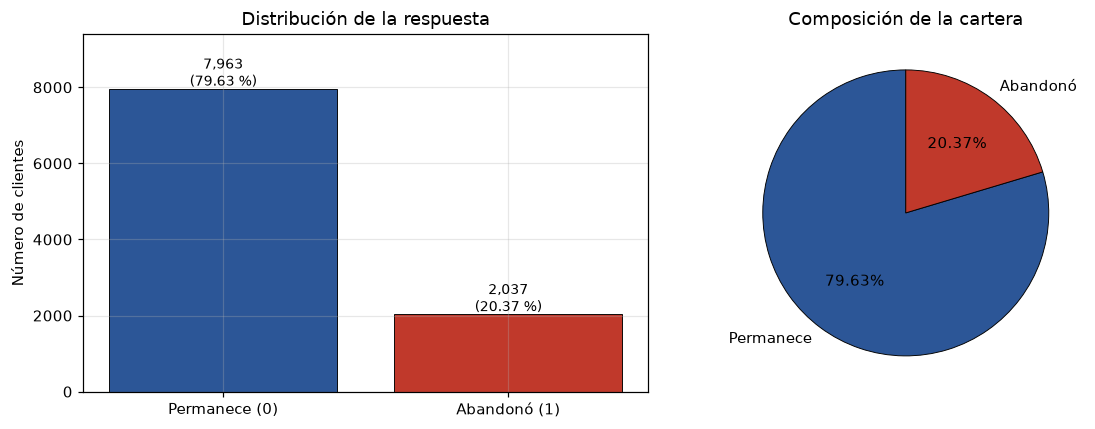

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Permanece (0)", "Abandonó (1)"], conteo.values,
            color=[COL_PERM, COL_ABAN], edgecolor="black", linewidth=0.6)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(datos)*100:.2f} %)",
                 ha="center", fontsize=9)
axes[0].set_ylabel("Número de clientes")
axes[0].set_title("Distribución de la respuesta")
axes[0].set_ylim(0, conteo.max() * 1.18)

axes[1].pie(conteo.values, labels=["Permanece", "Abandonó"],
            colors=[COL_PERM, COL_ABAN], autopct="%1.2f%%",
            startangle=90, wedgeprops={"edgecolor": "black", "linewidth": 0.6})
axes[1].set_title("Composición de la cartera")

plt.tight_layout()
plt.show()

In [10]:
print("DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS")
desc = datos[CUANTITATIVAS].describe().T
desc["asimetría"] = datos[CUANTITATIVAS].skew()
display(desc.round(2))

print(f"\nClientes con saldo exactamente 0: {int((datos['saldo']==0).sum())} "
      f"({(datos['saldo']==0).mean()*100:.2f} % de la base)")

DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS


,count,mean,std,min,25%,50%,75%,max,asimetría
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00,-0.07
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00,1.01
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00,0.01
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09,-0.14
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00,0.75
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48,0.00



Clientes con saldo exactamente 0: 3617 (36.17 % de la base)


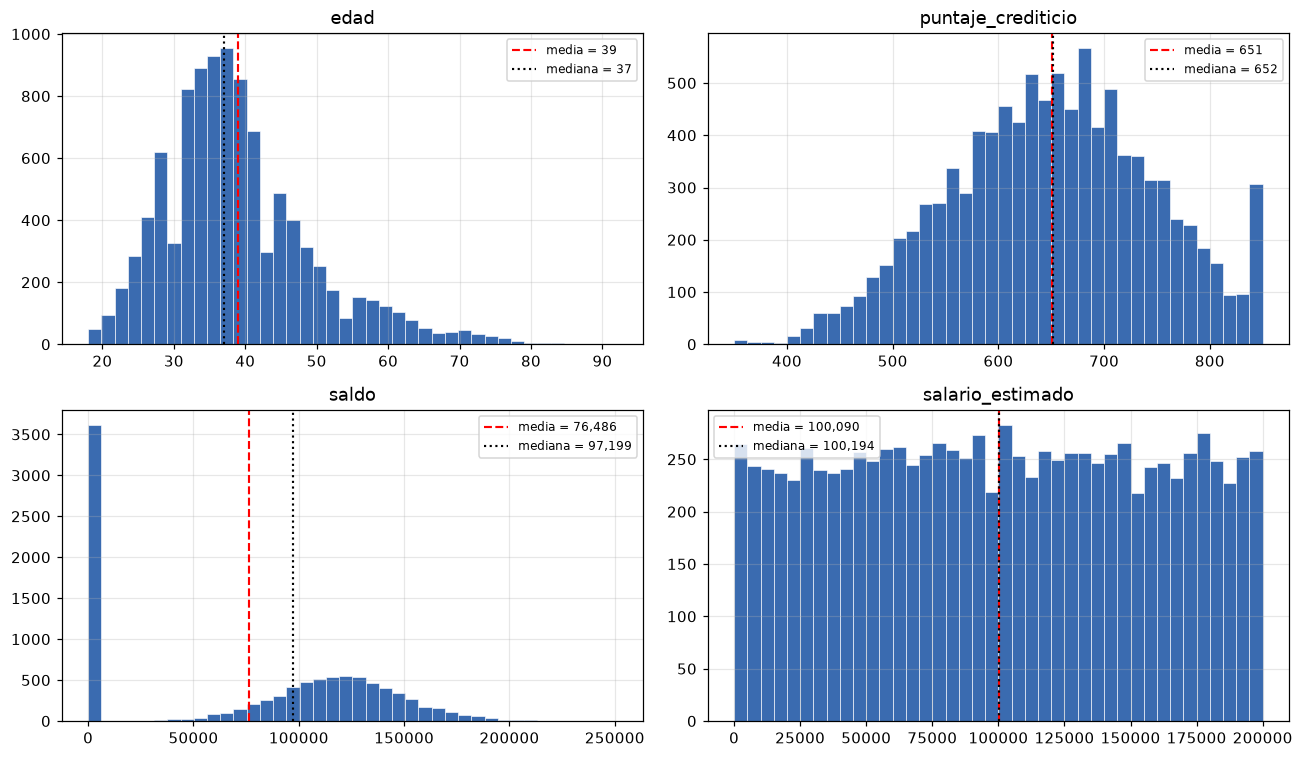

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, var in zip(axes.flat, ["edad", "puntaje_crediticio", "saldo",
                               "salario_estimado"]):
    ax.hist(datos[var], bins=40, color="#3A6BB0", edgecolor="white", linewidth=0.4)
    ax.axvline(datos[var].mean(), color="red", ls="--", lw=1.4,
               label=f"media = {datos[var].mean():,.0f}")
    ax.axvline(datos[var].median(), color="black", ls=":", lw=1.4,
               label=f"mediana = {datos[var].median():,.0f}")
    ax.set_title(var)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
print("TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS\n")
for var in ["pais", "sexo", "numero_productos", "miembro_activo", "tiene_tarjeta"]:
    t = pd.DataFrame({
        "Frecuencia": datos[var].value_counts(sort=False),
        "Porcentaje": (datos[var].value_counts(normalize=True, sort=False) * 100).round(2)})
    t.index.name = var
    display(t)

TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS



,Frecuencia,Porcentaje
pais,,
Francia,5014,50.14
Alemania,2509,25.09
España,2477,24.77


,Frecuencia,Porcentaje
sexo,,
Mujer,4543,45.43
Hombre,5457,54.57


,Frecuencia,Porcentaje
numero_productos,,
1,5084,50.84
3,266,2.66
2,4590,45.90
4,60,0.60


,Frecuencia,Porcentaje
miembro_activo,,
1,5151,51.51
0,4849,48.49


,Frecuencia,Porcentaje
tiene_tarjeta,,
1,7055,70.55
0,2945,29.45


### Respuestas (sección 2)

**5. ¿Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya
parece bueno si uno solo mira la *accuracy*?**

Abandonó el 20,37 % de la cartera: 2.037 clientes de 10.000. Permanece el 79,63 %, es decir
7.963. El desbalance es de casi 4 a 1 a favor de la clase 0.

Ese desbalance fija un piso engañoso para la exactitud. Un clasificador que ignore por completo
las variables y responda siempre «permanece» acierta en los 7.963 casos de la clase mayoritaria y
falla en los 2.037 restantes:

$$
\text{Exactitud del clasificador trivial} = \frac{7.963}{10.000} = 0{,}7963 \approx 79{,}6\,\%
$$

Casi un 80 % de aciertos sin haber aprendido nada. El problema es que su sensibilidad es
exactamente 0: no detecta a ni un solo cliente que se va, que es justamente lo único que le
interesa al área de retención.

De aquí se siguen dos consecuencias prácticas para el resto del taller:

- La exactitud solo es informativa comparada contra el 79,63 %. Un modelo con 82 % de acierto
  no es «bueno»: aporta apenas 2 puntos sobre no hacer nada.
- Hay que mirar sensibilidad y especificidad por separado (sección 6). Son los indicadores que
  distinguen un modelo útil de uno que simplemente se apoya en la clase mayoritaria.

**Lo que muestran las demás tablas.** `edad` está sesgada a la derecha (media 38,9; mediana 37;
máximo 92). `saldo` tiene una particularidad importante: 3.617 clientes (36,17 %) registran saldo exactamente cero, lo que produce una distribución bimodal (una masa en 0 y una campana alrededor
de 120.000) y no un simple sesgo. `salario_estimado` es prácticamente uniforme entre 11 y 200.000,
lo que hace sospechar que es una variable simulada y anticipa que aportará poco. En cuanto a los
factores, Francia concentra la mitad de la cartera (5.014) y Alemania y España se reparten el resto
por partes casi iguales; el 70,6 % tiene tarjeta y la base está casi partida en dos por
`miembro_activo` (51,5 % activos).

---
> 📌 Cierre de sección: `git commit -m "Punto 2: descriptivo univariado"` y `git push`.

---

# 3. Bivariado con la respuesta

Se compara cada variable entre quien abandona y quien permanece: boxplots y medianas para las
continuas, tablas cruzadas y ji-cuadrado para las categóricas.

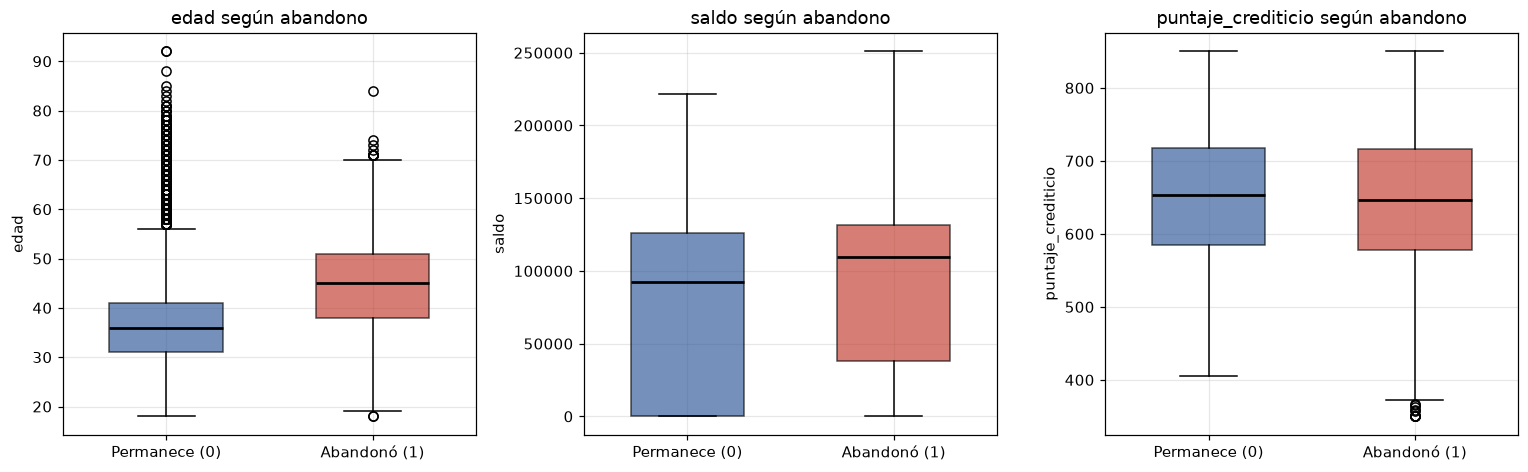

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, var in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [datos.loc[datos["abandono"] == k, var] for k in (0, 1)]
    bp = ax.boxplot(grupos, patch_artist=True, widths=0.55,
                    medianprops={"color": "black", "linewidth": 1.8})
    for caja, color in zip(bp["boxes"], [COL_PERM, COL_ABAN]):
        caja.set_facecolor(color)
        caja.set_alpha(0.65)
    # set_xticklabels en lugar del argumento labels=, que cambió de nombre
    # en matplotlib 3.9+ (labels -> tick_labels)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Permanece (0)", "Abandonó (1)"])
    ax.set_title(f"{var} según abandono")
    ax.set_ylabel(var)
plt.tight_layout()
plt.show()

In [14]:
print("MEDIANAS POR GRUPO")
medianas = datos.groupby("abandono")[CUANTITATIVAS].median().T
medianas.columns = ["Permanece (0)", "Abandonó (1)"]
medianas["Diferencia"] = medianas["Abandonó (1)"] - medianas["Permanece (0)"]
display(medianas.round(2))

print("MEDIAS POR GRUPO")
medias = datos.groupby("abandono")[CUANTITATIVAS].mean().T
medias.columns = ["Permanece (0)", "Abandonó (1)"]
medias["Diferencia"] = medias["Abandonó (1)"] - medias["Permanece (0)"]
display(medias.round(2))

MEDIANAS POR GRUPO


,Permanece (0),Abandonó (1),Diferencia
puntaje_crediticio,653.00,646.00,-7.00
edad,36.00,45.00,9.00
antiguedad,5.00,5.00,0.00
saldo,92072.68,109349.29,17276.61
numero_productos,2.00,1.00,-1.00
salario_estimado,99645.04,102460.84,2815.80


MEDIAS POR GRUPO


,Permanece (0),Abandonó (1),Diferencia
puntaje_crediticio,651.85,645.35,-6.50
edad,37.41,44.84,7.43
antiguedad,5.03,4.93,-0.10
saldo,72745.30,91108.54,18363.24
numero_productos,1.54,1.48,-0.07
salario_estimado,99738.39,101465.68,1727.29


In [15]:
# Contraste no paramétrico de la diferencia entre grupos (complementa el boxplot)
print("PRUEBA DE MANN-WHITNEY (H0: misma distribución en ambos grupos)\n")
filas = []
for var in CUANTITATIVAS:
    a = datos.loc[datos["abandono"] == 1, var]
    b = datos.loc[datos["abandono"] == 0, var]
    u, p = scipy.stats.mannwhitneyu(a, b, alternative="two-sided")
    filas.append({"Variable": var, "Mediana abandonó": a.median(),
                  "Mediana permanece": b.median(), "U": u, "p-value": p,
                  "Decisión (5%)": "Difieren" if p < 0.05 else "No difieren"})
display(pd.DataFrame(filas).round(4))

PRUEBA DE MANN-WHITNEY (H0: misma distribución en ambos grupos)



,Variable,Mediana abandonó,Mediana permanece,U,p-value,Decisión (5%)
0,puntaje_crediticio,646.00,653.00,7839548.0,0.0199,Difieren
1,edad,45.00,36.00,11874649.5,0.0000,Difieren
2,antiguedad,5.00,5.00,7948575.5,0.1622,No difieren
3,saldo,109349.29,92072.68,9371186.5,0.0000,Difieren
4,numero_productos,1.00,2.00,6830625.5,0.0000,Difieren
5,salario_estimado,102460.84,99645.04,8250768.0,0.2271,No difieren


In [16]:
def tabla_chi2(var, objetivo="abandono", datos=datos):
    '''Tabla cruzada, tasa de abandono por nivel y prueba ji-cuadrado.'''
    obs = pd.crosstab(datos[var], datos[objetivo])
    chi2, p, gl, esp = chi2_contingency(obs)
    n = obs.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(obs.shape) - 1)))

    resumen = obs.copy()
    resumen.columns = ["Permanece (0)", "Abandonó (1)"]
    resumen["Total"] = resumen.sum(axis=1)
    resumen["Tasa de abandono (%)"] = (resumen["Abandonó (1)"] /
                                       resumen["Total"] * 100).round(2)
    print(f"--- {var} vs {objetivo} ---")
    display(resumen)
    print(f"    Ji-cuadrado = {chi2:,.2f}   gl = {gl}   p-value = {p:.3e}")
    print(f"    V de Cramér = {v_cramer:.4f}   "
          f"(0 = sin asociación; 1 = asociación perfecta)\n")
    return {"Variable": var, "Chi2": chi2, "gl": gl, "p-value": p,
            "V de Cramér": v_cramer}


resultados_chi2 = [tabla_chi2(v) for v in
                   ["miembro_activo", "numero_productos", "pais", "sexo", "tiene_tarjeta"]]

--- miembro_activo vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
miembro_activo,,,,
0,3547,1302,4849,26.85
1,4416,735,5151,14.27


    Ji-cuadrado = 242.99   gl = 1   p-value = 8.786e-55
    V de Cramér = 0.1559   (0 = sin asociación; 1 = asociación perfecta)

--- numero_productos vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
numero_productos,,,,
1,3675,1409,5084,27.71
2,4242,348,4590,7.58
3,46,220,266,82.71
4,0,60,60,100.00


    Ji-cuadrado = 1,503.63   gl = 3   p-value = 0.000e+00
    V de Cramér = 0.3878   (0 = sin asociación; 1 = asociación perfecta)

--- pais vs abandono ---


...

    Ji-cuadrado = 301.26   gl = 2   p-value = 3.830e-66
    V de Cramér = 0.1736   (0 = sin asociación; 1 = asociación perfecta)

--- sexo vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
sexo,,,,
Mujer,3404,1139,4543,25.07
Hombre,4559,898,5457,16.46


    Ji-cuadrado = 112.92   gl = 1   p-value = 2.248e-26
    V de Cramér = 0.1063   (0 = sin asociación; 1 = asociación perfecta)

--- tiene_tarjeta vs abandono ---


,Permanece (0),Abandonó (1),Total,Tasa de abandono (%)
tiene_tarjeta,,,,
0,2332,613,2945,20.81
1,5631,1424,7055,20.18


    Ji-cuadrado = 0.47   gl = 1   p-value = 4.924e-01
    V de Cramér = 0.0069   (0 = sin asociación; 1 = asociación perfecta)



In [17]:
print("RANKING DE ASOCIACIÓN CON EL ABANDONO (variables categóricas)")
rank = (pd.DataFrame(resultados_chi2)
        .sort_values("V de Cramér", ascending=False)
        .reset_index(drop=True))
rank["Significativa (5%)"] = np.where(rank["p-value"] < 0.05, "Sí", "No")
display(rank.round(4))

RANKING DE ASOCIACIÓN CON EL ABANDONO (variables categóricas)


,Variable,Chi2,gl,p-value,V de Cramér,Significativa (5%)
0,numero_productos,1503.6294,3,0.0000,0.3878,Sí
1,pais,301.2553,2,0.0000,0.1736,Sí
2,miembro_activo,242.9853,1,0.0000,0.1559,Sí
3,sexo,112.9186,1,0.0000,0.1063,Sí
4,tiene_tarjeta,0.4713,1,0.4924,0.0069,No


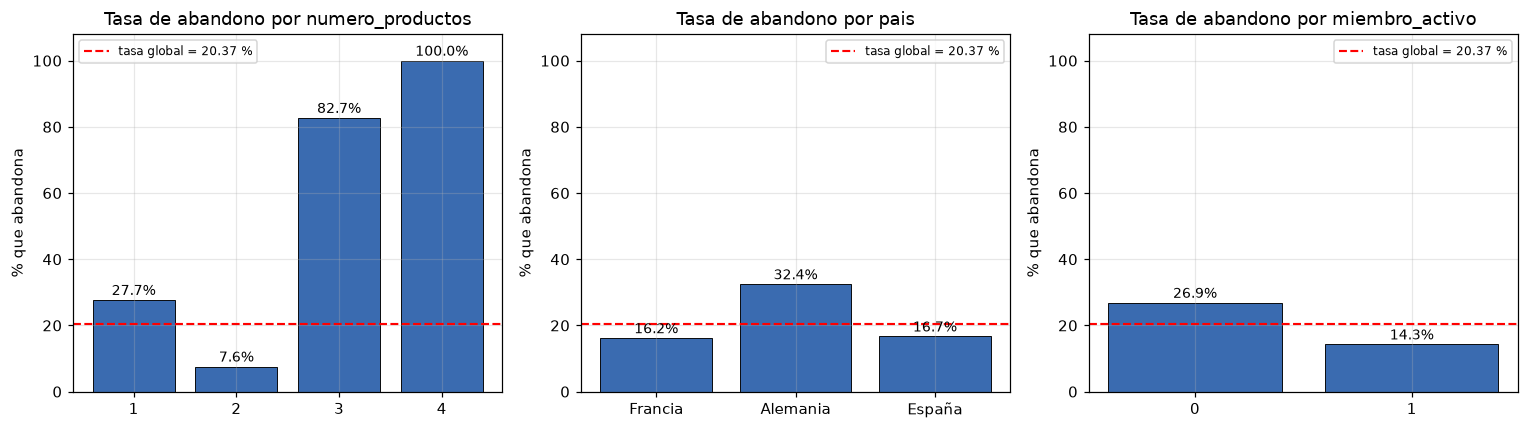

In [18]:
# Tasa de abandono por nivel: la lectura visual del ranking
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ["numero_productos", "pais", "miembro_activo"]):
    tasa = datos.groupby(var, observed=True)["abandono"].mean() * 100
    barras = ax.bar([str(i) for i in tasa.index], tasa.values,
                    color="#3A6BB0", edgecolor="black", linewidth=0.6)
    ax.axhline(TASA * 100, color="red", ls="--", lw=1.4,
               label=f"tasa global = {TASA*100:.2f} %")
    for b, v in zip(barras, tasa.values):
        ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%",
                ha="center", fontsize=9)
    ax.set_title(f"Tasa de abandono por {var}")
    ax.set_ylabel("% que abandona")
    ax.set_ylim(0, 108)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Respuestas (sección 3)

**6. Distribución de `edad` entre quien abandona y quien permanece.**

Es la diferencia más nítida entre las continuas. La mediana de quien abandona es 45 años frente
a 36 de quien permanece: nueve años de diferencia. El boxplot muestra la caja completa de
los que abandonan desplazada hacia arriba, con un recorrido intercuartílico que apenas se solapa
con el de quienes permanecen. La prueba de Mann-Whitney confirma que la diferencia no es
atribuible al azar ($p \approx 3{,}2\times10^{-230}$).

La lectura de negocio es que el riesgo de abandono se concentra en la franja madura de la
cartera, no en los clientes jóvenes.

**7. `saldo` y `puntaje_crediticio` entre los dos grupos.**

`saldo` se comporta de forma contraintuitiva: quien abandona tiene más saldo
(mediana 109.349 frente a 92.073). La diferencia es significativa ($p \approx 1{,}1\times10^{-28}$),
pero conviene no leerla de forma directa, y por dos motivos:

- El 36,17 % de la base tiene saldo exactamente cero, y ese cero se reparte de manera muy
  desigual: es el 39,14 % de quienes permanecen y solo el 24,55 % de quienes abandonan. La mediana
  del grupo que permanece está arrastrada hacia abajo por esa masa en cero.
- Ese cero está además confundido con el país (se verifica en la celda siguiente): en Alemania
  ningún cliente tiene saldo cero, mientras que en Francia y España cerca de la mitad lo tiene. Y
  Alemania es justamente el país con más abandono. Buena parte del «efecto saldo» es en realidad
  un efecto país.

`puntaje_crediticio` prácticamente no discrimina: mediana 646 frente a 653, siete puntos en
una escala de 350 a 850. El $p$-value es 0,0199 (formalmente significativo al 5 %), pero eso es un
artefacto del tamaño muestral: con $n = 10.000$ casi cualquier diferencia mínima resulta
significativa. Las cajas de los dos grupos se solapan casi por completo, y este resultado anticipa
que la variable no será significativa en el logit multivariado.

**8. `miembro_activo` y abandono. ¿Los clientes activos presentan menor abandono?**

**Sí, y la diferencia es grande.** Entre los inactivos abandona el 26,85 %; entre los activos,
el 14,27 %. La tasa de los inactivos casi duplica la de los activos.
$\chi^2 = 242{,}99$ con 1 grado de libertad y $p \approx 8{,}8\times10^{-55}$: se rechaza la
independencia de forma contundente.

Es además la variable más accionable del conjunto: a diferencia de la edad o del país, la
actividad del cliente sí puede intervenirse con campañas de reactivación.

**9. `numero_productos` y abandono. ¿Más productos se asocia siempre con menos abandono?**

**No. La relación no es monótona: tiene forma de U.**

| Productos | Clientes | Tasa de abandono |
|---:|---:|---:|
| 1 | 5.084 | 27,71 % |
| 2 | 4.590 | 7,58 % |
| 3 | 266 | 82,71 % |
| 4 | 60 | 100,00 % |

Pasar de uno a dos productos reduce el abandono en 20 puntos porcentuales, pero de dos en
adelante se dispara: con tres productos abandonan cuatro de cada cinco clientes, y los
sesenta clientes con cuatro productos abandonaron sin excepción.

La lectura natural es que dos productos describe al cliente vinculado y estable, mientras que tres
o cuatro no señalan mayor fidelidad sino probablemente una situación anómala: ventas cruzadas mal
dirigidas, o clientes en proceso de reestructurar su relación antes de cerrarla.

Este resultado tiene una consecuencia técnica que se verá en la sección 5: al entrar la variable
como continua, el logit le ajusta una sola pendiente y la U se promedia hasta casi
desaparecer.

**10. ¿Qué variable parece tener mayor relación con el abandono?**

Entre las categóricas, `numero_productos` por un margen amplio, y la justificación es la
V de Cramér, que normaliza el ji-cuadrado por el tamaño muestral y las dimensiones de la tabla
(el $\chi^2$ crudo no es comparable entre variables con distinto número de niveles):

| Variable | $\chi^2$ | gl | V de Cramér |
|---|---:|---:|---:|
| `numero_productos` | 1.503,63 | 3 | 0,3878 |
| `pais` | 301,26 | 2 | 0,1736 |
| `miembro_activo` | 242,99 | 1 | 0,1559 |
| `sexo` | 112,92 | 1 | 0,1063 |
| `tiene_tarjeta` | 0,47 | 1 | 0,0069 |

`numero_productos` más que duplica a la siguiente. Entre las continuas, la más asociada es
`edad`, con el $p$-value más extremo de todas las pruebas realizadas.

Conviene señalar el otro extremo: `tiene_tarjeta` no tiene ninguna relación con el abandono
($\chi^2 = 0{,}47$; $p = 0{,}492$; tasas de 20,81 % frente a 20,18 %). Es el primer candidato a
quedar fuera del modelo, y en la sección 5 se confirma.

In [19]:
# Verificación de la confusión entre saldo y país señalada en la respuesta 7
print("EL CERO DE saldo NO SE REPARTE AL AZAR ENTRE PAÍSES\n")
ceros = pd.DataFrame({
    "Clientes": datos.groupby("pais", observed=True).size(),
    "Con saldo = 0 (%)": (datos.groupby("pais", observed=True)["saldo"]
                          .apply(lambda s: (s == 0).mean() * 100)).round(2),
    "Tasa de abandono (%)": (datos.groupby("pais", observed=True)["abandono"]
                             .mean() * 100).round(2)})
display(ceros)

print("Tasa de abandono según el saldo sea cero o positivo:")
print(f"  saldo = 0 : {datos.loc[datos['saldo']==0, 'abandono'].mean()*100:.2f} %")
print(f"  saldo > 0 : {datos.loc[datos['saldo']>0, 'abandono'].mean()*100:.2f} %")

EL CERO DE saldo NO SE REPARTE AL AZAR ENTRE PAÍSES



,Clientes,Con saldo = 0 (%),Tasa de abandono (%)
pais,,,
Francia,5014,48.22,16.15
Alemania,2509,0.00,32.44
España,2477,48.41,16.67


Tasa de abandono según el saldo sea cero o positivo:
  saldo = 0 : 13.82 %
  saldo > 0 : 24.08 %


**Confirmación de la advertencia sobre `saldo`.** En Alemania ningún cliente registra saldo
cero, mientras que en Francia y España lo hace cerca de la mitad (48,22 % y 48,41 %). Como
Alemania duplica la tasa de abandono de los otros dos países (32,44 % frente a 16,15 % y 16,67 %),
tener saldo positivo y abandonar aparecen asociados a través del país, no necesariamente por
una relación propia.

Por eso la tasa de abandono de quienes tienen saldo cero (13,82 %) es menor que la de quienes
tienen saldo positivo (24,08 %): el grupo de saldo cero es casi enteramente francés y español. Es
un recordatorio de por qué el análisis bivariado no basta y hace falta el modelo multivariado, que
estima el efecto de cada variable manteniendo las demás constantes.

---
> 📌 Cierre de sección: `git commit -m "Punto 3: analisis bivariado"` y `git push`.